In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



In [2]:
iid = 0

path_to_data = f"/pscratch/sd/r/rmastand/muon_collider/npys/nuGun_pT_0_50/reco_h5/nuGun_pT_0_50_reco_{iid}.h5"

df = pd.read_hdf(path_to_data, key="df") 
print(df)



          event                    collection      Edep         t           x  \
0             0  InnerTrackerBarrelCollection  0.000028  4.001957 -503.471520   
1             0  InnerTrackerBarrelCollection  0.000035  3.993593 -503.892225   
2             0  InnerTrackerBarrelCollection  0.000125  2.825821 -549.297765   
3             0  InnerTrackerBarrelCollection  0.000079  2.749115  159.376294   
4             0  InnerTrackerBarrelCollection  0.000204  2.748186  159.384792   
...         ...                           ...       ...       ...         ...   
26580638      0        VertexEndcapCollection  0.000017  0.779050  -33.089746   
26580639      0        VertexEndcapCollection  0.000012  0.486435  -52.221875   
26580640      0        VertexEndcapCollection  0.000017  0.470859  -51.408205   
26580641      0        VertexEndcapCollection  0.000015  0.330662  -35.975104   
26580642      0        VertexEndcapCollection  0.000016  0.314854  -33.627993   

                   y       

In [3]:
NUM_R0WS = 26_580_643

In [4]:

# collections = [
#     "InnerTrackerBarrelCollection",
#     #"InnerTrackerEndcapCollection",
#     "OuterTrackerBarrelCollection",     
#     #"OuterTrackerEndcapCollection",  
#     "VertexBarrelCollection",   
#     #"VertexEndcapCollection",
# ]



# results_dir = {}

# for col_name in collections:

#     df_col =  df[df["collection"] == col_name]

#     results_dir[col_name] = {}

#     print(col_name)

#     #layer_var = df_col[["x"]].to_numpy().reshape(-1,)
#     layer_var = np.sqrt(df_col[["x"]].to_numpy().reshape(-1,)**2 +  df_col[["y"]].to_numpy().reshape(-1,)**2)
#     side = df_col[["side"]].to_numpy().reshape(-1,)
#     layer  = df_col[["layer"]].to_numpy().reshape(-1,)
#     inside_bounds  = df_col[["inside_bounds"]].to_numpy().reshape(-1,)


#     for s in set(list(side)):
#         for l in set(list(layer)):

#             results_dir[col_name][s,l] = {"starts":[], "stops":[]}

#             starts, stops = [], []
#             mask = (side == s) & (layer == l) & inside_bounds

            

#             loc_layer_var = layer_var[mask]

#             layer_bounds = np.linspace(loc_layer_var.min()-0.5, loc_layer_var.max()+0.5, 5000)

#             plt.figure(figsize=(20, 8))
#             n, _, _  =  plt.hist(loc_layer_var, bins = layer_bounds)
#             plt.title(f"{col_name}, side {s}, layer {l}")
            

#             for i in range(len(n)-1):
#                 if n[i] == 0 and n[i+1] > 0:
#                     results_dir[col_name][s,l]["starts"].append(layer_bounds[i+1])
#                     plt.axvline(layer_bounds[i+1], color = "r")
#                 if n[i] > 0 and n[i+1] == 0:
#                     results_dir[col_name][s,l]["stops"].append(layer_bounds[i+1])
#                     plt.axvline(layer_bounds[i+1], color = "g")

#             plt.yscale("log")

#             plt.show()



# print(results_dir)
 

In [5]:
print(results_dir)

NameError: name 'results_dir' is not defined

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45}
0 6639439 [2536659]
1 6639439 [2013445]
2 6639439 [2089335]


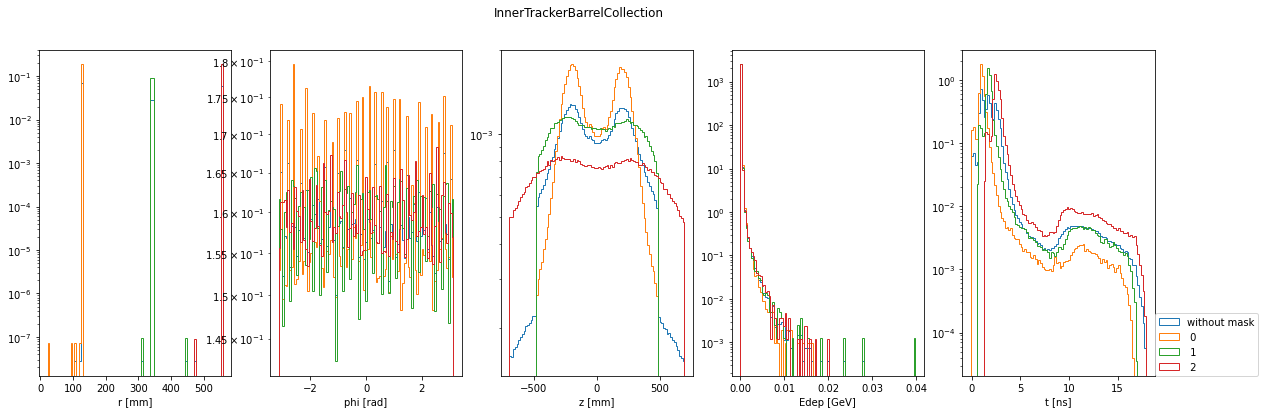

In [6]:
col_name = "VertexBarrelCollection"

df_col =  df[df["collection"] == col_name]


system =  df_col[["system"]].to_numpy() # collection
side =  df_col[["side"]].to_numpy() # \pm z
layer =  df_col[["layer"]].to_numpy() # r
module =  df_col[["module"]].to_numpy() # radial component
sensor =  df_col[["sensor"]].to_numpy()






r = np.sqrt(df_col[["x"]].to_numpy()**2 + df_col[["y"]].to_numpy()**2)
phi = np.arctan2(df_col[["y"]].to_numpy(), df_col[["x"]].to_numpy())
z = df_col[["z"]].to_numpy()
Edep = df_col[["Edep"]].to_numpy()
t = df_col[["t"]].to_numpy()

print(set(list(sensor.flatten())))

fig, ax = plt.subplots(1, 5, figsize = (20, 6))

ax[0].hist(r, bins = np.linspace(np.min(r), np.max(r), 100), histtype = "step", label = "without mask", density = True  )
ax[0].set_xlabel("r [mm]")
ax[1].hist(phi, bins = np.linspace(np.min(phi), np.max(phi), 100), range = (-np.pi, np.pi), histtype = "step", label = "without mask", density = True  )
ax[1].set_xlabel("phi [rad]")
ax[2].hist(z, bins = np.linspace(np.min(z), np.max(z), 100), range = (-4000, 4000), histtype = "step", label = "without mask", density = True  )
ax[2].set_xlabel("z [mm]")
ax[3].hist(Edep, bins = np.linspace(np.min(Edep), np.max(Edep), 100), histtype = "step", label = "without mask", density = True  )
ax[3].set_xlabel("Edep [GeV]")
ax[4].hist(t, bins = np.linspace(np.min(t), np.max(t), 100), histtype = "step", label = "without mask", density = True  )
ax[4].set_xlabel("t [ns]")

for i in range(len(set(list(layer.flatten())))):

    mask = (layer == i) 
    print(i, len(mask), sum(mask))
    ax[0].hist(r[mask], bins = np.linspace(np.min(r), np.max(r), 100), range = (0, 2000), histtype = "step", label = f" {i}", density = True  )
    ax[1].hist(phi[mask], bins = np.linspace(np.min(phi), np.max(phi), 100), range = (-np.pi, np.pi), histtype = "step", label = f" {i}", density = True  )
    ax[2].hist(z[mask], bins = np.linspace(np.min(z), np.max(z), 100), range = (-4000, 4000), histtype = "step", label = f" {i}", density = True  )
    ax[3].hist(Edep[mask], bins = np.linspace(np.min(Edep), np.max(Edep), 100), histtype = "step", label = f" {i}", density = True  )
    ax[4].hist(t[mask], bins = np.linspace(np.min(t), np.max(t), 100), histtype = "step", label = f" {i}", density = True  )


for i in range(5):
    ax[i].set_yscale("log")
ax[4].legend(loc = (1, 0))

plt.suptitle(col_name)

plt.show()


In [7]:
collections = [
    "InnerTrackerBarrelCollection",
    "InnerTrackerEndcapCollection",
    "OuterTrackerBarrelCollection",     
    
    "OuterTrackerEndcapCollection",  
    "VertexBarrelCollection",   
    "VertexEndcapCollection",
]

for col in collections:
    
    df_col = df[df["collection"] == col]
    print(len(df_col))
    df_col = df_col[df_col["inside_bounds"] == True]
    print(col, len(df_col))



    df_col_selected = df_col[["Edep", "x", "y", "z", "t", "side", "layer", "module", "sensor"]].to_numpy()

    np.save(f"/pscratch/sd/r/rmastand/muon_collider/npys/nuGun_pT_0_50/{col}_SimTrackerHit_conditional_reco_{iid}.npy", df_col_selected)

6639439
InnerTrackerBarrelCollection 3926196
2360215
InnerTrackerEndcapCollection 1614679
6787500
OuterTrackerBarrelCollection 3280678
2825825
OuterTrackerEndcapCollection 1465825
2641857
VertexBarrelCollection 2129166
5325807
VertexEndcapCollection 4096371
